In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

## MultiServerMCPClient

사전에 `mcp_server_remote.py` 를 실행해둡니다. 터미널을 열고 가상환경이 활성화 되어 있는 상태에서 서버를 실행해 주세요.

> 명령어
```bash
source .dotenv/script/activate
python mcp_server_remote.py
```

`async with` 로 일시적인 Session 연결을 생성 후 해제

In [2]:
# 오류가 나는 이유: langchain-mcp-adapters 0.1.0부터 MultiServerMCPClient는 async context manager(`async with`) 또는 __aenter__를 사용할 수 없습니다.
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.

# python .\mcp_rag_sse.py
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8101/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_react_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "Jaeho"})


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

Hello! How can I assist you with "Jaeho"? Are you looking for information about a person named Jaeho, or something else related to that name? Please provide more details.


In [3]:
await astream_graph(agent, {"messages": "jaeho"})


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
Hello! How can I assist you with "jaeho"? Are you looking for information about a person named Jaeho, or something else related to that term? Please provide more details.

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c'}, id='run-a40eece4-b2b3-4a74-8666-805e3c8a131b'),
 'metadata': {'langgraph_step': 1,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:217f4251-7ec8-5054-d2c4-0648af0289c3',
  'checkpoint_ns': 'agent:217f4251-7ec8-5054-d2c4-0648af0289c3',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

In [4]:
# 에이전트 생성
# client.get_tools()는 coroutine이므로 await로 받아야 함
tools = await client.get_tools()
agent = create_react_agent(model, tools)

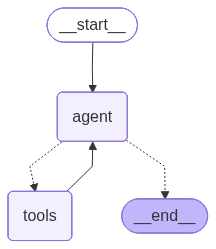

In [5]:
agent

In [6]:
await astream_graph(agent, {"messages": "Jaeho"})


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
Hello! How can I assist you with "Jaeho"? Are you looking for information about a person named Jaeho, or something else related to that name? Please provide more details.

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c'}, id='run-32ff10c0-1aef-4883-8b76-bb2240dfb135'),
 'metadata': {'langgraph_step': 1,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:4f84e2c2-b3de-5889-f516-11447a14a214',
  'checkpoint_ns': 'agent:4f84e2c2-b3de-5889-f516-11447a14a214',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

## Stdio 통신 방식

Stdio 통신 방식은 로컬 환경에서 사용하기 위해 사용합니다.

- 통신을 위해 표준 입력/출력 사용

참고: 아래의 python 경로는 수정하세요!

In [7]:
# 첫번째 방식

In [8]:
import sys, os, nest_asyncio, asyncio
from pathlib import Path
from mcp.client.stdio import stdio_client, StdioServerParameters
from mcp import ClientSession
from langchain_mcp_adapters.tools import load_mcp_tools
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

nest_asyncio.apply()
os.environ.setdefault("PYTHONUNBUFFERED", "1")

async def run_mcp_client_stdio_in_notebook(
    server_file: str = "mcp_server_local(stdio).py",
    user_prompt: str = "Jaeho",
):
    server_path = Path(server_file).resolve()
    errlog_path = server_path.parent / "mcp_stderr.log"
    if not server_path.exists():
        raise FileNotFoundError(f"서버 스크립트 없음: {server_path}")

    if sys.platform == "win32":
        try: asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        except: pass

    server = StdioServerParameters(
        command=sys.executable,
        args=["-u", str(server_path)],
        cwd=str(server_path.parent),
        env=os.environ.copy(),
    )

    try:
        with open(errlog_path, "wb") as err:
            async with stdio_client(server, errlog=err) as (read, write):
                async with ClientSession(read, write) as session:
                    await session.initialize()
                    tools = await load_mcp_tools(session)
                    agent = create_react_agent(ChatOpenAI(model="gpt-4.1-mini", temperature=0), tools)
                    inputs = {"messages": [HumanMessage(content=user_prompt, name="user")]}
                    return [event async for event in agent.astream(inputs)]
    except Exception as e:
        tail = ""
        try:
            if errlog_path.exists():
                data = errlog_path.read_bytes()
                tail = (data[-4096:] if len(data) > 4096 else data).decode("utf-8", "ignore")
        except: pass
        raise RuntimeError(f"STDIO MCP 실행 실패: {e}\n\n=== server stderr (tail) ===\n{tail}") from e


In [9]:
# === mcp_stdio_helper.py (또는 노트북 첫 셀) ===
import sys, os, asyncio
from pathlib import Path
from contextlib import asynccontextmanager

# 주피터 환경 권장: nest_asyncio
try:
    import nest_asyncio
    nest_asyncio.apply()
except Exception:
    pass

os.environ.setdefault("PYTHONUNBUFFERED", "1")  # 서브프로세스 버퍼링 방지

from mcp.client.stdio import stdio_client, StdioServerParameters
from mcp import ClientSession
from langchain_mcp_adapters.tools import load_mcp_tools

def _win_proactor_policy():
    if sys.platform == "win32":
        try:
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        except Exception:
            pass

@asynccontextmanager
async def start_stdio_mcp(
    server_file: str,
    *,
    python: str = sys.executable,
    cwd: str | None = None,
    env: dict | None = None,
    errlog_path: str | None = "mcp_stderr.log",
):
    """
    STDIO MCP 서버를 서브프로세스로 올리고 ClientSession과 변환된 LangChain tools를 반환합니다.
    사용 예:
        async with start_stdio_mcp("server_stdio.py") as (session, tools):
            ...
    """
    _win_proactor_policy()

    server_path = Path(server_file).resolve()
    if not server_path.exists():
        raise FileNotFoundError(f"서버 스크립트가 없습니다: {server_path}")

    params = StdioServerParameters(
        command=python,
        args=["-u", str(server_path)],            # -u: unbuffered
        cwd=str(cwd or server_path.parent),
        env=(env or os.environ).copy(),
    )

    err_fp = None
    try:
        if errlog_path:
            err_fp = open(errlog_path, "wb")
        async with stdio_client(params, errlog=err_fp) as (read, write):
            async with ClientSession(read, write) as session:
                await session.initialize()
                tools = await load_mcp_tools(session)
                try:
                    yield session, tools
                finally:
                    # 세션 종료는 with 블록 해제 시 자동
                    pass
    except Exception as e:
        # 진단을 돕기 위해 stderr tail 표시
        tail = ""
        try:
            if errlog_path and Path(errlog_path).exists():
                data = Path(errlog_path).read_bytes()
                tail = (data[-4096:] if len(data) > 4096 else data).decode("utf-8", "ignore")
        except Exception:
            pass
        raise RuntimeError(f"STDIO MCP 연결 실패: {e}\n\n=== server stderr (tail) ===\n{tail}") from e
    finally:
        if err_fp:
            err_fp.close()


In [10]:
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# 1) 서버 올리고 도구 받기
async with start_stdio_mcp("mcp_server_local(stdio).py") as (session, tools):
    # 2) 에이전트 구성 & 실행
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    agent = create_react_agent(model, tools)

    inputs = {"messages": [HumanMessage(content="jaeho", name="user")]}
    async for event in agent.astream(inputs):
        print(event)

    # # 한 번에 결과만:
    # result = await agent.ainvoke(inputs)
    # print(result)


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_G98J11WBYL8ZSLoBTV6sSDBr', 'function': {'arguments': '{"name": "jaeho"}', 'name': 'get_name'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 53, 'total_tokens': 85, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CTYlcnch0hfXoAybGVPMCrSSHipEr', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-64adb9c8-d531-4cc6-ab23-4f9f74715c5f-0', tool_calls=[{'name': 'get_name', 'args': {'name': 'jaeho'}, 'id': 'call_G98J11WBYL8ZSLoBTV6sSDBr', 'type': 'tool_call'}], usage_metadata={'input_tokens': 53, 'output_tokens': 32, 'total_tokens': 85, 'input_token_details': {'audio': 0, 'ca

In [11]:
# 같은 디렉터리에 server_stdio.py 가 있어야 합니다.
# server_stdio.py 안에서는 반드시 로그 print 를 stderr 로 보내세요:
# print("MCP running...", file=sys.stderr)
results = await run_mcp_client_stdio_in_notebook(
    server_file="mcp_server_local(stdio).py",
    user_prompt="Jaeho",
)

for r in results:
    print(r)


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_3zBhjBw4xnyDRsg4jF0fAufj', 'function': {'arguments': '{"name": "Jaeho"}', 'name': 'get_name'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 53, 'total_tokens': 85, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CTYlhrld8UK02CGEvDIrT5mLNLRql', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-f8a12462-d83b-4e57-af1a-59e48b27e060-0', tool_calls=[{'name': 'get_name', 'args': {'name': 'Jaeho'}, 'id': 'call_3zBhjBw4xnyDRsg4jF0fAufj', 'type': 'tool_call'}], usage_metadata={'input_tokens': 53, 'output_tokens': 32, 'total_tokens': 85, 'input_token_details': {'audio': 0, 'ca

----------

In [12]:
# 두번째 방식

In [13]:
import sys, os, nest_asyncio, asyncio
from pathlib import Path
from mcp.client.stdio import stdio_client, StdioServerParameters
from mcp import ClientSession
from langchain_mcp_adapters.tools import load_mcp_tools
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

nest_asyncio.apply()
os.environ.setdefault("PYTHONUNBUFFERED", "1")

async def run_mcp_client_stdio_in_notebook(
    server_file: str = "mcp_rag_stdio.py",
    user_prompt: str = "Jaeho",
):
    server_path = Path(server_file).resolve()
    errlog_path = server_path.parent / "mcp_stderr.log"
    if not server_path.exists():
        raise FileNotFoundError(f"서버 스크립트 없음: {server_path}")

    if sys.platform == "win32":
        try: asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        except: pass

    server = StdioServerParameters(
        command=sys.executable,
        args=["-u", str(server_path)],
        cwd=str(server_path.parent),
        env=os.environ.copy(),
    )

    try:
        with open(errlog_path, "wb") as err:
            async with stdio_client(server, errlog=err) as (read, write):
                async with ClientSession(read, write) as session:
                    await session.initialize()
                    tools = await load_mcp_tools(session)
                    agent = create_react_agent(ChatOpenAI(model="gpt-4.1-mini", temperature=0), tools)
                    inputs = {"messages": [HumanMessage(content=user_prompt, name="user")]}
                    return [event async for event in agent.astream(inputs)]
    except Exception as e:
        tail = ""
        try:
            if errlog_path.exists():
                data = errlog_path.read_bytes()
                tail = (data[-4096:] if len(data) > 4096 else data).decode("utf-8", "ignore")
        except: pass
        raise RuntimeError(f"STDIO MCP 실행 실패: {e}\n\n=== server stderr (tail) ===\n{tail}") from e


In [14]:
# === mcp_stdio_helper.py (또는 노트북 첫 셀) ===
import sys, os, asyncio
from pathlib import Path
from contextlib import asynccontextmanager

# 주피터 환경 권장: nest_asyncio
try:
    import nest_asyncio
    nest_asyncio.apply()
except Exception:
    pass

os.environ.setdefault("PYTHONUNBUFFERED", "1")  # 서브프로세스 버퍼링 방지

from mcp.client.stdio import stdio_client, StdioServerParameters
from mcp import ClientSession
from langchain_mcp_adapters.tools import load_mcp_tools

def _win_proactor_policy():
    if sys.platform == "win32":
        try:
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        except Exception:
            pass

@asynccontextmanager
async def start_stdio_mcp(
    server_file: str,
    *,
    python: str = sys.executable,
    cwd: str | None = None,
    env: dict | None = None,
    errlog_path: str | None = "mcp_stderr.log",
):
    """
    STDIO MCP 서버를 서브프로세스로 올리고 ClientSession과 변환된 LangChain tools를 반환합니다.
    사용 예:
        async with start_stdio_mcp("server_stdio.py") as (session, tools):
            ...
    """
    _win_proactor_policy()

    server_path = Path(server_file).resolve()
    if not server_path.exists():
        raise FileNotFoundError(f"서버 스크립트가 없습니다: {server_path}")

    params = StdioServerParameters(
        command=python,
        args=["-u", str(server_path)],            # -u: unbuffered
        cwd=str(cwd or server_path.parent),
        env=(env or os.environ).copy(),
    )

    err_fp = None
    try:
        if errlog_path:
            err_fp = open(errlog_path, "wb")
        async with stdio_client(params, errlog=err_fp) as (read, write):
            async with ClientSession(read, write) as session:
                await session.initialize()
                tools = await load_mcp_tools(session)
                try:
                    yield session, tools
                finally:
                    # 세션 종료는 with 블록 해제 시 자동
                    pass
    except Exception as e:
        # 진단을 돕기 위해 stderr tail 표시
        tail = ""
        try:
            if errlog_path and Path(errlog_path).exists():
                data = Path(errlog_path).read_bytes()
                tail = (data[-4096:] if len(data) > 4096 else data).decode("utf-8", "ignore")
        except Exception:
            pass
        raise RuntimeError(f"STDIO MCP 연결 실패: {e}\n\n=== server stderr (tail) ===\n{tail}") from e
    finally:
        if err_fp:
            err_fp.close()


In [15]:
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# 1) 서버 올리고 도구 받기
async with start_stdio_mcp("mcp_rag_stdio.py") as (session, tools):
    # 2) 에이전트 구성 & 실행
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    agent = create_react_agent(model, tools)

    inputs = {"messages": [HumanMessage(content="jaeho", name="user")]}
    async for event in agent.astream(inputs):
        print(event)

    # # 한 번에 결과만:
    # result = await agent.ainvoke(inputs)
    # print(result)


{'agent': {'messages': [AIMessage(content='Hello! How can I assist you with "jaeho"? Are you looking for information about a person named Jaeho, or something else related to that name? Please provide more details.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 40, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'id': 'chatcmpl-CTYlpAqcRT5m1JQDLgj2HuJ8WyySM', 'finish_reason': 'stop', 'logprobs': None}, id='run-41bced7e-0e25-4ec4-99c6-bc4fcf00a372-0', usage_metadata={'input_tokens': 40, 'output_tokens': 40, 'total_tokens': 80, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [16]:
# 같은 디렉터리에 server_stdio.py 가 있어야 합니다.
# server_stdio.py 안에서는 반드시 로그 print 를 stderr 로 보내세요:
# print("MCP running...", file=sys.stderr)
results = await run_mcp_client_stdio_in_notebook(
    server_file="mcp_rag_stdio.py",
    user_prompt="DNA 서열 예측",
)

for r in results:
    print(r)


{'agent': {'messages': [AIMessage(content='DNA 서열 예측에 대해 구체적으로 어떤 정보를 원하시나요? 예를 들어, 특정 DNA 서열의 기능 예측, 돌연변이 예측, 또는 새로운 서열 생성 등 다양한 예측이 가능합니다. 원하시는 예측 종류나 분석 목적을 알려주시면 더 정확한 도움을 드릴 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 42, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'id': 'chatcmpl-CTYlxrTjiOdIdA9iRKYAYQlH99WjV', 'finish_reason': 'stop', 'logprobs': None}, id='run-38052abb-5139-4657-9d7d-0895e1643372-0', usage_metadata={'input_tokens': 42, 'output_tokens': 72, 'total_tokens': 114, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


# `mcp_local(stdio).py` 에서 돌려보기

In [17]:
# from mcp import ClientSession, StdioServerParameters
# from mcp.client.stdio import stdio_client
# from langgraph.prebuilt import create_react_agent
# from langchain_mcp_adapters.tools import load_mcp_tools

# # command 위치가 맞는지 확인하려면, 실제 파이썬 인터프리터 경로가 맞는지 확인해야 합니다.
# # 예를 들어, 윈도우 환경에서는 보통 "python" 또는 "python.exe" 경로가 다를 수 있습니다.
# # 아래처럼 sys.executable을 사용하면 현재 실행 중인 파이썬 경로를 쓸 수 있습니다.

# import sys

# server_params = StdioServerParameters(
#     command=sys.executable,  # 현재 파이썬 인터프리터 경로 사용
#     args=["mcp_local_local(stdio).py"],
# )

# # StdIO 클라이언트를 사용하여 서버와 통신
# async with stdio_client(server_params) as (read, write):
#     # 클라이언트 세션 생성
#     async with ClientSession(read, write) as session:
#         # 연결 초기화
#         await session.initialize()

#         # MCP 도구 로드
#         tools = await load_mcp_tools(session)
#         print(tools)

#         # 에이전트 생성
#         agent = create_react_agent(model, tools)

#         # 에이전트 응답 스트리밍
#         await astream_graph(agent, {"messages": "jaeho"})

# Retriever MCP (mcp_rag_sse.py)

mcp_rag_sse.py가 켜져야 하며,
docker에서 qdrant에 데이터 정보가 저장되어 있으므로, docker를 반드시 켜야한다.

In [18]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8102/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_react_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "spri에 미드저니에 대한 정보가 있어?"})


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_MECuUyjSHML1vp8ecifVRCQF)
 Call ID: call_MECuUyjSHML1vp8ecifVRCQF
  Args:
    query: 미드저니

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: retrieve

- n AI 이미지 생성 플랫폼 미드저니(Midjourney)가 2025년 6월 19일 비디오 생성 모델 'V1'을 출시
- V1은 이미지를 동영상으로 변환하는 모델로, 미드저니 플랫폼에서 제작된 이미지나 외부 이미지를 바탕으로 동영상을 생성하며, '자동' 설정 시에는 모션 프롬프트가 자동으로 생성되고 '수동' 설정을 선택하면 사용자 지시에 따라 사물이나 장면의 움직임을 생성
- 사용자는 움직임 강도를 피사체와 카메라가 모두 움직이는 '하이 모션(High Motion)'과 카메라는 거의 고정되어 있고 피사체가 천천히 움직이도록 연출 '로우 모션(Low Motion)' 중에서 선택 가능
- 웹 전용 모델인 V1은 1회 동영상 생성 작업으로 5초 길이의 동영상 4개를 제작하며, 생성된 동영상은 한 번에 4초씩 최대 4회까지 영상 길이를 확장할 수 있도록 허용
<!-- image -->

## 기업 ･ 산업

<!-- image -->

## 미드저니, 첫 번째 비디오 생성 AI 모델 'V1' 출시

## KEY Contents

- n 미드저니가 1회 작업으로 5초 길이의 동영상 4개를 제작할 수 있는 

In [19]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8102/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_react_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "단백질 서열 예측"})


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_290pKFeHcx0syGQjr3hjDlMc)
 Call ID: call_290pKFeHcx0syGQjr3hjDlMc
  Args:
    query: 단백질 서열 예측

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: retrieve

<!-- image -->

## 기술 ･ 연구

<!-- image -->

## 구글 딥마인드, 인간 DNA 염기서열 분석 AI 모델 '알파게놈' 공개

## KEY Contents

- n 구글 딥마인드가 인간 DNA 염기서열을 입력하면 수천 개에 달하는 분자적 특성을 예측할 수 있는 AI 모델 '알파게놈'을 개발하고 비상업적 연구용으로 API로 공개
- n 알파게놈은 유전체의 98%에 해당하는 단백질 비부호화 영역을 해독할 수 있으며, 광범위한 유전체 예측 벤치마크 평가에서 기존 최고 성능 모델과 동등하거나 더 뛰어난 수준의 성능을 달성

## £ 알파게놈, 최대 100만 개의 DNA 염기서열을 바탕으로 수천 종류의 분자적 특성 예측
* 유전체의 2%를 차지하는 단백질 부호화 영역 내 변이 영향의 분류에 특화된 AI 모델   ** 유전체 중 단백질로 발현되지 않는 영역
- 유전자 활동 조율에 필수적이면서 질병과 관련된 다양한 변이를 포함하는 단백질 비부호화 영역의 광범위한 염기서열과 변이의 해석을 지원하며, 돌연변이가 발생한 염기서열과 발생하지 않은 염기서열의 예측값을 비교하여 유전적

# Manse tool MCP (mcp_manse_sse.py)

mcp_manse_sse.py가 켜져야 하며,
docker에서 qdrant에 데이터 정보가 저장되어 있으므로, docker를 반드시 켜야한다.

In [20]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8103/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_react_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "1995년 3월 28일 12시 30분 출생 사주봐줘. 자세히 풀이까지 해줘"})


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  parse_saju_input (call_I1MEBKS0qfK6uu8QEE6ZOII7)
 Call ID: call_I1MEBKS0qfK6uu8QEE6ZOII7
  Args:
    text: 1995년 3월 28일 12시 30분 남자

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: parse_saju_input

파싱 결과:
{
  "year": 1995,
  "month": 3,
  "day": 28,
  "hour": 12,
  "minute": 30,
  "is_male": true,
  "is_leap_month": false
}

🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  calculate_saju (call_6a4e3HpfwkCP9oIywPlOqDti)
 Call ID: call_6a4e3HpfwkCP9oIywPlOqDti
  Args:
    year: 1995
    month: 3
    day: 28
    hour: 12
    minute: 30
    is_male: True
    is_leap_month: False

🔄 Node: tools 🔄
- - - - - - - - - -

## SSE 방식과 StdIO 방식 혼합 사용

- 파일: `mcp_server_rag.py` 는 StdIO 방식으로 통신
- `langchain-dev-docs` 는 SSE 방식으로 통신
- `manse-tool`은 SSEㅂ 방식으로 통신
SSE 방식과 StdIO 방식을 혼합하여 사용합니다.

`mcp_client_openai.py` 참고

In [21]:
# import sys
# # 아래 코드는 Jupyter 노트북이 아닌, 터미널(명령 프롬프트, bash 등)에서 실행할 수 있는 Python 파일 예시입니다.
# # 파일명 예시: mcp_multiserver_client.py

# import sys
# import asyncio
# from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
# from langchain_openai import ChatOpenAI

# async def main():
#     model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

#     # 1. 다중 서버 MCP 클라이언트 생성 (document-retriever는 stdio, langchain-dev-docs는 sse)
#     client = MultiServerMCPClient(
#         {
#             "document-retriever": {
#                 "command": sys.executable,  # 현재 파이썬 실행 파일 경로
#                 "args": ["mcp_server_local(stdio).py"],  # mcp_server_rag.py의 경로를 실제 위치로 수정
#                 "transport": "stdio",
#             },
#             "langchain-dev-docs": {
#                 "url": "https://teddynote.io/mcp/langchain/sse",
#                 "transport": "sse",
#             },
#             "manse-tool":{
#                 "url": "http://localhost:8102/sse",
#                 "transport": "sse"
#             }
#         }
#     )

#     # 2. 도구 목록 받아오기
#     tools = await client.get_tools()

#     # 3. LangGraph 에이전트 생성
#     agent = create_react_agent(model, tools)

#     # 4. 에이전트에게 질문하기 (예시)
#     from utils import ainvoke_graph
#     answer = await ainvoke_graph(agent, {"messages": "1995년 3월 28일 12시 30분 출생 사주봐줘. 자세히 풀이까지 해줘"})
#     print(answer)

# if __name__ == "__main__":
#     asyncio.run(main())

# Multi SSE MCP

In [38]:
# Jupyter 노트북 환경에서는 stdio transport가 정상적으로 동작하지 않습니다.
# (UnsupportedOperation: fileno 에러 발생)
# 따라서 stdio 대신 sse 방식만 사용하거나, stdio는 터미널에서만 사용하세요.

from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# document-retriever도 sse 방식으로 예시를 변경 (실제 서버 주소로 수정 필요)
client = MultiServerMCPClient(
    {
        "mcp-rag": {
            "url": "http://localhost:8102/sse",  # 실제 SSE 서버 주소로 변경
            "transport": "sse",
        },
        "langchain-dev-docs": {
            "url": "https://teddynote.io/mcp/langchain/sse",
            "transport": "sse",
        },
        "manse-tool":{
            "url": "http://localhost:8103/sse",
            "transport": "sse"
        }
    }
)

tools = await client.get_tools()

langgraph 의 `create_react_agent` 를 사용하여 에이전트를 생성합니다.

In [39]:
# from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
# from langchain_openai import ChatOpenAI
# from utils import ainvoke_graph, astream_graph
# from langgraph.checkpoint.memory import MemorySaver
# from langchain_core.runnables import RunnableConfig
# from langchain_openai import ChatOpenAI

# model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

prompt = (
    "You are a smart agent. Answer in Korean.\n"
    "- `mcp-rag` : search SPRI AI docs; cite title/date.\n"
    "- `langchain-dev-docs` : search LangChain/LangGraph docs; return API path + short code.\n"
    "- `manse-tool` : when birth date and time are provided, use it to read Saju (Four Pillars) and return pillars/day-master/five-elements.\n"
)

# 오류 원인: client.get_tools()는 awaitable 객체(코루틴)인데, await 없이 바로 전달해서 발생합니다.
# Jupyter 환경에서는 await를 써야 하므로 아래처럼 수정해야 합니다.
agent = create_react_agent(
    model, tools, prompt=prompt, checkpointer=MemorySaver()
)

In [40]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "DNA 서열 예측에서 최고 성능 개수는?"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
<!-- image -->

## 기술 ･ 연구

<!-- image -->

## 구글 딥마인드, 인간 DNA 염기서열 분석 AI 모델 '알파게놈' 공개

## KEY Contents

- n 구글 딥마인드가 인간 DNA 염기서열을 입력하면 수천 개에 달하는 분자적 특성을 예측할 수 있는 AI 모델 '알파게놈'을 개발하고 비상업적 연구용으로 API로 공개
- n 알파게놈은 유전체의 98%에 해당하는 단백질 비부호화 영역을 해독할 수 있으며, 광범위한 유전체 예측 벤치마크 평가에서 기존 최고 성능 모델과 동등하거나 더 뛰어난 수준의 성능을 달성

## £ 알파게놈, 최대 100만 개의 DNA 염기서열을 바탕으로 수천 종류의 분자적 특성 예측
* SpliceAI, Borzoi, ProCapNet, Panglon, ChromBPNet, Orca, Enformer, AbSplice
- DNA 서열 예측에서는 24개 평가 과제 중 22개에서 최고 성능을 보였고, 변이의 조절 효과 예측에서는 26개 평가 과제 중 24개에서 기존 최고 성능 모델과 동등하거나 능가하는 기록을 달성
- n 그러나 알파게놈은 유전자와 해당 기능을 조절하는 요소가 10만 개 이상 염기쌍으로 떨어져 있을 경우의 영향을 포착하는 데는 어려움을 겪는 등 한계도 내포
- 연구진은 알파게놈이 분자 수준을 넘어 유전적 변이가 어떻게 복잡한 형질이나 질병으로 이어지는지를 밝히는 것처럼 광범위한 생물학적 과정을 다루어야 하는 사례에는 적용되기 어렵다고 부연
- 연구진은 향후 이러한 격차를 해소하기 위해 피드백을 받아 모델을 지속적으로 개선할 계획으로, 비상업적 연구용으로 '알파게놈 API'를 통해 모델을 프리뷰로 공개
* 유전체의 2%를 차지하는 단백질 부호화 영역 내 변이 

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c'}, id='run-0728ac56-1572-49d1-be92-383103cf363f'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 3,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:2d0e4f19-6191-e06a-8b8e-a809470b3244',
  'checkpoint_ns': 'agent:2d0e4f19-6191-e06a-8b8e-a809470b3244',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

In [41]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "`retriever`도구를 통해서, 미드저니에 버전에 대해서 설명해줘"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
<!-- image -->

## 기업 ･ 산업

<!-- image -->

## 미드저니, 첫 번째 비디오 생성 AI 모델 'V1' 출시

## KEY Contents

- n 미드저니가 1회 작업으로 5초 길이의 동영상 4개를 제작할 수 있는 비디오 생성 모델 'V1'을 출시하고 여타 비디오 생성 모델보다 25배 이상 저렴한 가격을 책정했다고 강조
- n 미드저니는 실시간 오픈월드 시뮬레이션이 가능한 AI 모델 개발을 궁극적 목표로 제시하고, 2026년에 3D 모델과 실시간 처리 모델을 출시한 뒤 각 모델을 하나로 통합할 계획이라고 설명

## £ 'V1', 미드저니에서 생성한 이미지나 외부 이미지를 동영상으로 변환
- n 한편, 그록 4 출시 이후 그록 4가 반유대주의 메시지를 게시하거나 민감한 질문 답변 시 일론 머스크의 X를 검색해 해당 주제에 대한 머스크의 의견을 답변에 반영한다는 논란이 제기
- 이에 xAI는 그록 4와 관련된 주요 논란에 대해 사과하며, 답변 시 이전 버전 그록이나 일론 머스크, xAI가 밝힌 특정 신념이 아니라 독자적 분석에 기반하도록 시스템 프롬프트를 업데이트했다고 설명
- n AI 이미지 생성 플랫폼 미드저니(Midjourney)가 2025년 6월 19일 비디오 생성 모델 'V1'을 출시
- V1은 이미지를 동영상으로 변환하는 모델로, 미드저니 플랫폼에서 제작된 이미지나 외부 이미지를 바탕으로 동영상을 생성하며, '자동' 설정 시에는 모션 프롬프트가 자동으로 생성되고 '수동' 설정을 선택하면 사용자 지시에 따라 사물이나 장면의 움직임을 생성
- 사용자는 움직임 강도를 피사체와 카메라가 모두 움직이는 '하이 모션(High Motion)'과 카메라는 거의 고정되어 있고 피사체가 천천히 움직이도록

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c'}, id='run-f4387da4-c854-4514-b55f-b81d1e46f91a'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 8,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:a0e02e47-590b-8968-1d13-bdefd43491d5',
  'checkpoint_ns': 'agent:a0e02e47-590b-8968-1d13-bdefd43491d5',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

In [42]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "`retriever`도구를 통해서, 미드저니에 버전에 대해서 설명해줘"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
앞서 검색한 내용에 따르면, 미드저니는 2025년 6월 19일에 첫 번째 비디오 생성 AI 모델 'V1'을 출시했습니다. 이 모델은 미드저니에서 생성한 이미지나 외부 이미지를 바탕으로 5초 길이의 동영상 4개를 한 번에 제작할 수 있습니다. 자동 설정 시 모션 프롬프트가 자동 생성되고, 수동 설정 시 사용자가 움직임을 직접 지시할 수 있습니다. 움직임 강도는 '하이 모션'과 '로우 모션' 중 선택 가능하며, 생성된 동영상은 최대 4회까지 4초씩 연장할 수 있습니다. 미드저니는 2026년에 3D 모델과 실시간 처리 모델을 출시하고 이를 통합하는 것을 목표로 하고 있습니다.

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c'}, id='run-b053442f-dddf-4254-901e-b8cb37e4cdad'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 11,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:1dfe3428-f4aa-c8eb-03de-48aa421e44b5',
  'checkpoint_ns': 'agent:1dfe3428-f4aa-c8eb-03de-48aa421e44b5',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

In [43]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "1995년 3월 28일 12시 30분 출생"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
파싱 결과:
{
  "year": 1995,
  "month": 3,
  "day": 28,
  "hour": 12,
  "minute": 30,
  "is_male": true,
  "is_leap_month": false
}
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
=== 사주팔자 ===
년주(年柱): 을해
월주(月柱): 기묘
일주(日柱): 무오
시주(時柱): 무오
일간(日干): 무
현재 나이: 30세 / 한국식 나이: 31세
기준 시점: 2025-10-23 04:45:49

=== 오행 강약 (8점 만점) ===
목: 2점
화: 2점
토: 3점
금: 0점
수: 1점

=== 십신 분석 ===
년주: 천간:정관, 지지:편재(70%), 지지:편관(30%)
월주: 천간:겁재, 지지:정관(100%)
일주: 지지:정인(70%), 지지:겁재(30%)
시주: 지지:정인(70%), 지지:겁재(30%)

=== 대운 (정밀 계산) ===
5세: 무인 (2000년 ~ 2009년)
15세: 정축 (2010년 ~ 2019년)
25세: 병자 (2020년 ~ 2029년)
35세: 을해 (2030년 ~ 2039년)
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
1995년 3월 28일 12시 30분 출생 남성의 사주팔자는 다음과 같습니다.

- 년주: 을해
- 월주: 기묘
- 일주: 무오
- 시주: 무오
- 일간: 무

오행 강약 점수는 목 2점, 화 2점, 토 3점, 금 0점, 수 1점입니다

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c'}, id='run-c4d229ce-a334-4875-a995-81955b9125f2'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 18,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:6cd6a42c-19e3-92fb-7d85-a381856b1969',
  'checkpoint_ns': 'agent:6cd6a42c-19e3-92fb-7d85-a381856b1969',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

In [44]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {"messages": "langgraph-dev-docs 참고해서 hierarchical-rag 의 정의, 코드에 대해서 알려줘"},
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
오류: 지식 기반 검색 중 문제가 발생했습니다. Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************h68A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 LangChain/LangGraph 지식 기반 검색에 API 키 오류가 발생하여 hierarchical-rag에 대한 정의와 코드를 바로 제공하기 어렵습니다. 대신 LangChain 공식 문서나 GitHub 저장소에서 hierarchical-rag 관련 내용을 확인하시면 도움이 될 것입니다. 필요하시면 다른 방법으로도 도움을 드릴 수 있습니다.

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862'}, id='run-f883fdee-525b-4933-8805-786ec0e42ea9'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 23,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent', 'start:agent', 'tools'),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:b997b817-bd40-2a4e-7ef1-5aebc02431ad',
  'checkpoint_ns': 'agent:b997b817-bd40-2a4e-7ef1-5aebc02431ad',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0}}

## LangChain 에 통합된 도구 + MCP 도구

여기서는 LangChain 에 통합된 도구를 기존의 MCP 로만 이루어진 도구와 함께 사용이 가능한지 테스트 합니다.

In [29]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(max_result=3, topic="news", days=7)

tools = await client.get_tools()

tools_with_tavily = tools + [tavily]

In [30]:
tools_with_tavily

[StructuredTool(name='retrieve', description='\n    Retrieves information from the document database based on the query.\n\n    This function creates a retriever, queries it with the provided input,\n    and returns the concatenated content of all retrieved documents.\n\n    Args:\n        query (str): The search query to find relevant information\n\n    Returns:\n        str: Concatenated text content from all retrieved documents\n    ', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'retrieveArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000001DAC5B4B7E0>),
 StructuredTool(name='list_of_langchain_documents', description='Retrieves a list of available LangChain and LangGraph documentation resources.\n\n    This function fetches a YAML file from GitHub containing a curated list of\n    documentation sources related to LangCh

In [31]:
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig

# 재귀 제한 및 스레드 아이디 설정
config = RunnableConfig(recursion_limit=30, thread_id=3)

# 프롬프트 설정
prompt = "You are a smart agent with various tools. Answer questions in Korean."

# 에이전트 생성
agent = create_react_agent(model, tools_with_tavily, prompt=prompt, checkpointer=MemorySaver())

In [32]:
# TavilySearch 도구를 통해서,
response = await astream_graph(agent, {"messages": "TavilySearch 도구를 통해서, DeFi Technologies INC 주식의 전망에 대해서 알려줘"}, config=config)
print(response)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "DeFi Technologies INC 주식 전망", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/news/tesla-full-self-driving-fsd-120000565.html", "title": "From Tesla’s Full Self-Driving (FSD) V14.1.2 in autonomous vehicles to the era of self-driving wealth - Yahoo Finance", "score": 0.5409972, "published_date": "Wed, 22 Oct 2025 12:00:00 GMT", "content": "According to a Miami-based consulting forecast, by 2028, the total value of tokenized assets could exceed $16 trillion, driven by institutional adoption and the demand for transparent, verifiable sources of yield.  \n BC DeFi’s model allows users to participate directly using stablecoins such as USDT, while AI algorithms manage allocation and automatically distribute verified on-chain returns. [...] New York City, NY, Oct. 22, 2025 (GLOBE NEWSWIRE) --Whe

## Smithery 에서 제공하는 MCP 서버

- 링크: https://smithery.ai/

사용한 도구 목록은 아래와 같습니다.

- Sequential Thinking: https://smithery.ai/server/@smithery-ai/server-sequential-thinking
  - 구조화된 사고 프로세스를 통해 역동적이고 성찰적인 문제 해결을 위한 도구를 제공하는 MCP 서버
- Desktop Commander: https://smithery.ai/server/@wonderwhy-er/desktop-commander
  - 다양한 편집 기능으로 터미널 명령을 실행하고 파일을 관리하세요. 코딩, 셸 및 터미널, 작업 자동화

**참고**

- smithery 에서 제공하는 도구를 JSON 형식으로 가져올때, 아래의 예시처럼 `"transport": "stdio"` 로 꼭 설정해야 합니다.

In [33]:
# langchain_mcp_adapters → mcp.client.stdio가 STDIO 연결로 MCP 서버를 띄우려 함

# Jupyter/IPython의 sys.stderr는 진짜 파일 핸들이 아니라서 fileno()가 없습니다 → UnsupportedOperation: fileno

# Windows의 asyncio 서브프로세스 백엔드가 노트북 환경과 맞물려 NotImplementedError → Popen 폴백 순으로 진입하다가 stderr 핸들에서 최종적으로 실패

In [34]:
# from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
# from langchain_openai import ChatOpenAI

# # LLM 모델 초기화
# model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# # 1. 클라이언트 생성
# client = MultiServerMCPClient(
#     {
#         "server-sequential-thinking": {
#             "command": "cmd",
#             "args": [
#                 "/c",
#                 "npx",
#                 "-y",
#                 "@smithery/cli@latest",
#                 "run",
#                 "@smithery-ai/server-sequential-thinking",
#                 "--key",
#                 "92f8aa68-b8c4-4053-94ee-63d4d0d90992",
#                 "--profile",
#                 "allied-bird-lzqFcM"
#             ],
#             "transport": "stdio"
#         },
#         "desktop-commander": {
#             "command": "cmd",
#             "args": [
#                 "/c",
#                 "npx",
#                 "-y",
#                 "@smithery/cli@latest",
#                 "run",
#                 "@wonderwhy-er/desktop-commander",
#                 "--key",
#                 "92f8aa68-b8c4-4053-94ee-63d4d0d90992"
#             ],
#             "transport": "stdio"
#         },
#         "document-retriever": {
#             "command": "./.venv/bin/python",
#             # mcp_server_rag.py 파일의 절대 경로로 업데이트해야 합니다
#             "args": ["./mcp_server_rag.py"],
#             # stdio 방식으로 통신 (표준 입출력 사용)
#             "transport": "stdio",
#         },
#     }
# )

# # 2. 명시적으로 연결 초기화 (context manager 사용 불가, 공식 가이드에 따라 아래처럼 사용)
# # await client.__aenter__()  # 이 방식은 더 이상 지원되지 않음

# # 아래와 같이 도구를 불러오세요.
# tools = await client.get_tools()

In [ ]:
from mcp_stdio_simple import 